## Additional updates for data visualization

For use with our UMAP explorer app, we need a few extra updates:
1. Normalize (but not log transform) the RNA and ADT data
2. Log transform some of the quantitative QC metadata columns
3. Select and rename columns for display in the app

In [1]:
from datetime import date

import hisepy
import os

import numpy as np
import pandas as pd
import polars as pl

import mudata as md

import scanpy as sc
import muon as mu

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
mu.set_options(pull_on_update=False)

In [3]:
if not os.path.isdir('output'):
    os.mkdir('output')

## Helper functions

In [4]:
def read_feat(in_file):
    with open(in_file, "r") as file:
        feat = [line.rstrip() for line in file]
        header = feat.pop(0)
    return feat

In [5]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

In [6]:
def normalize_mdata(mdata):
    sc.pp.normalize_total(
        mdata.mod['rna'],
        target_sum = 1e4
    )
    
    mdata.mod['adt'].X = mdata.mod['adt'].X.astype('float32')
    mu.prot.pp.clr(
        mdata.mod['adt']
    )
    
    return mdata

## Read .h5mu files from HISE

In [7]:
in_uuids = {
    '4h': '060a5005-fbb4-4363-80fe-5c81b96a94d1',
    '24h': 'e0765310-239f-4895-9a7c-56124e4207d5',
    '72h': 'ce83e66b-9e56-47ac-a6cb-e24cd5595e38'
}

In [8]:
in_files = {}
for k, uuid in in_uuids.items():
    in_files[k] = hisepy.cache_files([uuid])[0]

2026-06-10 13:13:02,211 INFO [hisepy.logging:175] logging 6042 139255235082048 Calling cache_files
2026-06-10 13:13:06,719 INFO [hisepy.logging:208] logging 6042 139255235082048 Finished cache_files, success=True, time_elapsed=3.015s
2026-06-10 13:13:06,720 INFO [hisepy.logging:175] logging 6042 139255235082048 Calling cache_files
2026-06-10 13:13:10,719 INFO [hisepy.logging:208] logging 6042 139255235082048 Finished cache_files, success=True, time_elapsed=2.563s
2026-06-10 13:13:10,720 INFO [hisepy.logging:175] logging 6042 139255235082048 Calling cache_files
2026-06-10 13:13:14,628 INFO [hisepy.logging:208] logging 6042 139255235082048 Finished cache_files, success=True, time_elapsed=2.557s


## Normalize matrices

In [9]:
mu_dict = {}
for k, h5mu in in_files.items():
    mdata = mu.read_h5mu(h5mu)
    mdata = normalize_mdata(mdata)
    mu_dict[k] = mdata

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/muon/_prot/preproc.py:219: UserWarning: adata.X is sparse but not in CSC format. Converting to CSC.
  warn("adata.X is sparse but not in CSC format. Converting to CSC.")
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/muon/_prot/preproc.py:219: UserWarning: adata.X is sparse but not in CSC format. Converting to CSC.
  warn("adata.X is sparse but not in CSC format. Converting to CSC.")
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/muon/_prot/preproc.py:219: UserWarning: adata.X is sparse but not in CSC format. Converting to CSC.
  warn("adata.X is sparse but not in CSC format. Converting to CSC.")


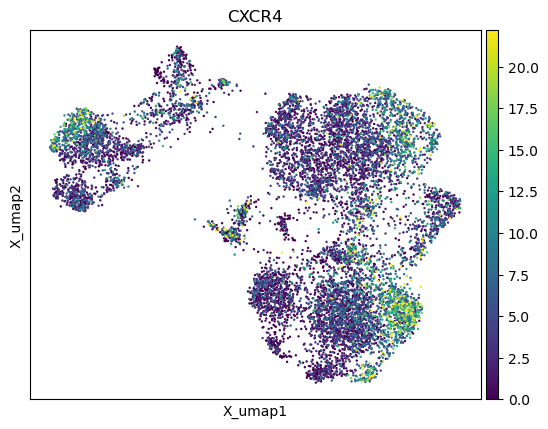

In [10]:
mu.pl.umap(
    mu_dict['24h'], 
    color = 'CXCR4',
    vmax = 'p99'
)

## Update cell metadata

In [11]:
rename_columns = {
    'specimen.specimenGuid': 'Specimen GUID',
    'well_id': 'Well ID',
    'Treatment': 'Treatment',
    'Timepoint': 'Timepoint',
    'Cell Type': 'Cell Type',
    'rna.frac_mito_umis': 'RNA: Frac. Mito. UMIs',
    'atac.frac_mito': 'ATAC: Frac. Mito. Fragments'
}

In [12]:
log_columns = {
    'rna.n_reads': 'RNA: Log10(N Reads)',
    'rna.n_umis': 'RNA: Log10(N UMIs)',
    'rna.n_mito_umis': 'RNA: Log10(N Mito. UMIs)',
    'rna.n_genes': 'RNA: Log10(N Genes)',
    'adt.n_umis': 'ADT: Log10(N UMIs)',
    'atac.n_fragments': 'ATAC: Log10(N Fragments)',
    'atac.n_unique': 'ATAC: Log10(N Unique Fragments)',
    'atac.n_mito': 'ATAC: Log10(N Mito. UMIs + 1)'
}

In [13]:
def log_obs_cols(mdata, log_columns):
    for k, v in log_columns.items():
        if k == 'atac.n_mito':
            mdata.obs[v] = np.log10(mdata.obs[k] + 1)
        else:
            mdata.obs[v] = np.log10(mdata.obs[k])
        mdata.obs = mdata.obs.drop(k, axis = 1)
    return mdata

In [14]:
for k, mdata in mu_dict.items():
    mdata = log_obs_cols(mdata, log_columns)
    mu_dict[k] = mdata

In [15]:
for k, mdata in mu_dict.items():
    keep_cols = list(rename_columns.values()) + list(log_columns.values())
    mdata.obs = mdata.obs.rename(rename_columns, axis = 1)
    mdata.obs = mdata.obs[keep_cols].copy()
    mu_dict[k] = mdata

In [16]:
mu_dict['4h'].obs.head()

,Specimen GUID,Well ID,Treatment,Timepoint,Cell Type,RNA: Frac. Mito. UMIs,ATAC: Frac. Mito. Fragments,RNA: Log10(N Reads),RNA: Log10(N UMIs),RNA: Log10(N Mito. UMIs),RNA: Log10(N Genes),ADT: Log10(N UMIs),ATAC: Log10(N Fragments),ATAC: Log10(N Unique Fragments),ATAC: Log10(N Mito. UMIs + 1)
barcodes,,,,,,,,,,,,,,,
46059f68fb7b11ed933dc6f18f77c1a7,PC02184-047,EXP-00454-P1C2W7,Bortezomib,T4,CD4 Naive,0.131278,0.000000,3.899821,3.054996,2.173186,2.806180,3.112940,3.807197,3.022428,0.000000
99cab48afb8011edb519365d129239e0,PC02184-047,EXP-00454-P1C1W8,Bortezomib,T4,CD4 Naive,0.085747,0.000177,3.916559,3.413132,2.346353,3.146748,3.088490,4.653955,4.005695,0.954243
ccc6bb4afb7b11ed8d7c62b1232be981,PC02184-047,EXP-00454-P1C1W5,Bortezomib,T4,CD4 CM,0.057026,0.000027,4.030681,3.501607,2.257679,3.229426,3.023664,4.560767,4.018825,0.301030
2f0d7cf6fb8311ed9fae72654f839162,PC02184-047,EXP-00454-P1C2W4,Bortezomib,T4,CD8 Naive,0.064349,0.017327,4.488057,3.762003,2.570543,3.402089,3.390759,3.836830,3.456214,2.079181
18a4477cfb8011ed8e8a7625f34dfd6b,PC02184-047,EXP-00454-P1C2W5,Bortezomib,T4,CD4 Naive,0.077755,0.000140,4.073425,3.457579,2.348305,3.181844,3.283075,4.154728,3.588047,0.477121


In [18]:
out_4h = 'output/tcell-vrd_4h_sampled_subset_vis_{d}.h5mu'.format(d = date.today())
mu_dict['4h'].write_h5mu(out_4h)
out_24h = 'output/tcell-vrd_24h_sampled_subset_vis_{d}.h5mu'.format(d = date.today())
mu_dict['24h'].write_h5mu(out_24h)
out_72h = 'output/tcell-vrd_72h_sampled_subset_vis_{d}.h5mu'.format(d = date.today())
mu_dict['72h'].write_h5mu(out_72h)

## Upload results to HISE

In [19]:
study_space_uuid = '40df6403-29f0-4b45-ab7d-f46d420c422e'
title = 'VRd TEA-seq TE .h5mu files for vis {d}'.format(d = date.today())

In [20]:
search_id = element_id()
search_id

'arsenic-antimony-silicon'

In [21]:
in_files = list(in_uuids.values())

In [22]:
in_files

['060a5005-fbb4-4363-80fe-5c81b96a94d1',
 'e0765310-239f-4895-9a7c-56124e4207d5',
 'ce83e66b-9e56-47ac-a6cb-e24cd5595e38']

In [23]:
out_files = [out_4h, out_24h, out_72h]
out_files

['output/tcell-vrd_4h_sampled_subset_vis_2026-06-10.h5mu',
 'output/tcell-vrd_24h_sampled_subset_vis_2026-06-10.h5mu',
 'output/tcell-vrd_72h_sampled_subset_vis_2026-06-10.h5mu']

In [24]:
import session_info
session_info.show()

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  mod_version = _find_version(mod.__version__)


In [25]:
hisepy.upload_files(
    files = out_files,
    study_space_id = study_space_uuid,
    title = title,
    input_file_ids = in_files,
    destination = search_id
)

2026-06-10 13:14:36,580 INFO [hisepy.logging:175] logging 6042 139255235082048 Calling upload_files


Please provide input of comma separated sample ids for the files being uploaded. If you do not have any sample ids, press enter:  


2026-06-10 13:16:27,139 INFO [hisepy.logging:175] logging 6042 139255235082048 Calling get_default_store
2026-06-10 13:16:29,124 INFO [hisepy.logging:208] logging 6042 139255235082048 Finished get_default_store, success=True, time_elapsed=0.410s
2026-06-10 13:16:50,226 INFO [hisepy.logging:208] logging 6042 139255235082048 Finished upload_files, success=True, time_elapsed=132.117s


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': '48f5802a-5239-4d2a-a9ca-856185ca3cf5',
 'ProcessId': '770ea500-27f3-4179-ad44-33716f870375',
 'WorkflowId': '397a3c82-8c49-4d03-878a-4b817de7f748',
 'FileIds': ['937c36a2-2edb-4392-8aae-1f36d48e42f2',
  'c42f8e0f-7462-4752-8263-3ee6ba8e3b49',
  '3e350630-53ce-42bf-8dd9-8a860e804424']}